In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Loading data
model = pd.read_csv('modeling_data.csv')

In [4]:
# Dropping leakage columns

drop_cols = [
    'HV271',
    'HV206',
    'HV207',
    'HV208',
    'HV209',
    'HV024'
]

model = model.drop(columns=drop_cols)


In [6]:
model.shape

(21545, 21)

In [5]:
model.head()

,age,slept_under_treated_net,slept_under_llin,survey_year,malaria_positive,HV216,HV219,HV220,HV201,HV205,...,HML1,HV270,HV025,state,avg_temperature,relative_humidity,wind_speed,precipitation,max_temperature,min_temperature
0,3,0,0,2010,1,10,2,23,32,22,...,0,3,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
1,4,1,1,2010,1,3,2,27,32,31,...,1,2,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
2,4,0,0,2010,1,4,1,35,31,31,...,0,2,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
3,2,0,0,2010,1,2,1,18,43,31,...,0,2,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
4,1,0,0,2010,0,1,2,35,43,43,...,0,2,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3


In [6]:
# Separate Features and Target variables X and Y

X = model.drop('malaria_positive', axis=1)  # feature variables
y = model['malaria_positive']   # Target variable

# Check:

print(X.shape)
print(y.shape)

(21545, 20)
(21545,)


In [7]:
# Define Categorical and Numerical Variables

cat_cols = [
    'state',
    'slept_under_treated_net',
    'slept_under_llin',
    'survey_year',
    'HV219',
    'HV201',
    'HV205',
    'HV226',
    'HV270',
    'HV025'
]

num_cols = [
    'age',
    'HV216',
    'HV220',
    'HML1',
    'avg_temperature',
    'relative_humidity',
    'wind_speed',
    'precipitation',
    'max_temperature',
    'min_temperature'
]

# Check:

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 10
Numerical: 10


In [8]:
# Check Class Imbalance
print(y.value_counts())

# And in percentage
print(y.value_counts(normalize=True)*100)

malaria_positive
0    15757
1     5788
Name: count, dtype: int64
malaria_positive
0    73.135298
1    26.864702
Name: proportion, dtype: float64


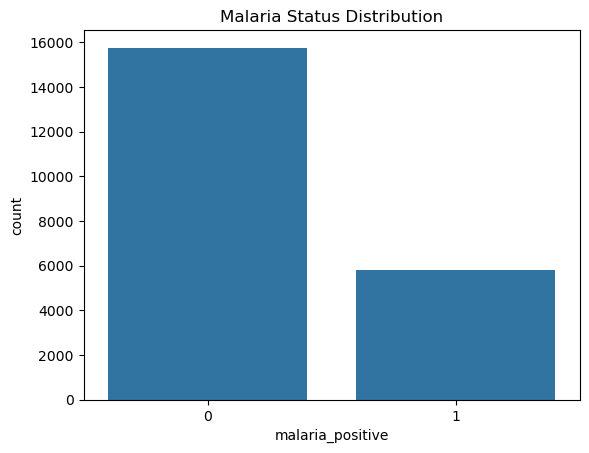

In [9]:
# Ploting the class distribution of the target variable

sns.countplot(
    x=y
)

plt.title('Malaria Status Distribution')
plt.show()

In [10]:
# Train-Test Split

# Use stratification because malaria classes are imbalanced.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check:

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(17236, 20)
(4309, 20)
(17236,)
(4309,)


# Build Preprocessing Pipelines because Machine learning algorithms cannot directly understand text format, we need to recode into number format

In [11]:
# Numerical Pipeline

numeric_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='median')),
        ('scaler',
         StandardScaler())
    ]
)

# Categorical Pipeline

categorical_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='most_frequent')),
        ('encoder',
         OneHotEncoder(
             handle_unknown='ignore'
         ))
    ]
)

In [12]:
# Combine Everything

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            num_cols
        ),
        (
            'cat',
            categorical_transformer,
            cat_cols
        )
    ]
)

# Model Building

In [22]:
# I needed to install xgboost because it wasn't on my libraries
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.1 MB/s eta 0:00:33
    --------------------------------------- 1.0/69.5 MB 2.1 MB/s eta 0:00:33
    --------------------------------------- 1.6/69.5 MB 2.1 MB/s eta 0:00:32
   - -------------------------------------- 2.1/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.4/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.9/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 3.4/69.5 MB 2.1 MB/s eta 0:00:32
   -- ------------------------------------- 3.9/69.5 MB 2.1 MB/s eta 0:00:31
   -- ------------------------------------- 4.2/69.5 MB 2.1 MB/s eta 0:00:32
   -- ------------------------------------- 4.7/69.5 MB 2.1 MB/s eta 0:00:32
   --- -------------

In [27]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.7 MB/s eta 0:00:00


In [13]:
# importing libraries
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21545 entries, 0 to 21544
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      21545 non-null  int64  
 1   slept_under_treated_net  21545 non-null  int64  
 2   slept_under_llin         21545 non-null  int64  
 3   survey_year              21545 non-null  int64  
 4   malaria_positive         21545 non-null  int64  
 5   HV216                    21545 non-null  int64  
 6   HV219                    21545 non-null  int64  
 7   HV220                    21545 non-null  int64  
 8   HV201                    21545 non-null  int64  
 9   HV205                    21545 non-null  int64  
 10  HV226                    21545 non-null  int64  
 11  HML1                     21545 non-null  int64  
 12  HV270                    21545 non-null  int64  
 13  HV025                    21545 non-null  int64  
 14  state                 

In [14]:
# Define Target
target = 'malaria_positive'

In [15]:
# Separate X and y
X = model.drop(columns=[target])
y = model[target]

# Check:

print(X.shape)
print(y.shape)

(21545, 20)
(21545,)


In [16]:
# Identify Categorical and Numerical Columns
cat_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

num_cols = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print(cat_cols)
print(num_cols)

['state']
['age', 'slept_under_treated_net', 'slept_under_llin', 'survey_year', 'HV216', 'HV219', 'HV220', 'HV201', 'HV205', 'HV226', 'HML1', 'HV270', 'HV025', 'avg_temperature', 'relative_humidity', 'wind_speed', 'precipitation', 'max_temperature', 'min_temperature']


# LOGISTICS REGRESSION

In [18]:
# Build Logistic Regression

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     LogisticRegression(
         max_iter=1000,
         class_weight='balanced',
         random_state=42
     ))
])

# Training the model:

log_model.fit(
    X_train,
    y_train
)

# Predicting the model:

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(
    X_test
)[:,1]

# Evaluate Logistic Regression
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.86      0.61      0.71      3151
           1       0.41      0.73      0.52      1158

    accuracy                           0.64      4309
   macro avg       0.63      0.67      0.62      4309
weighted avg       0.74      0.64      0.66      4309



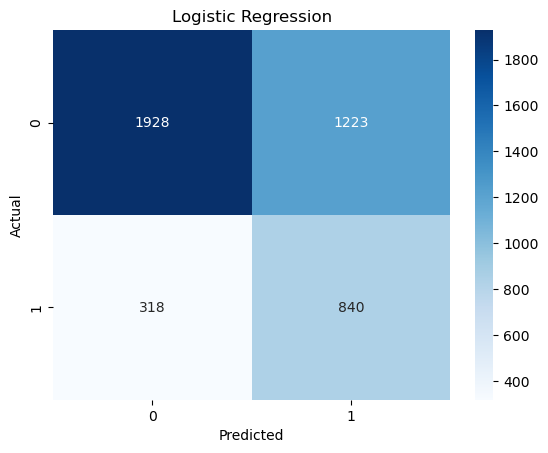

In [19]:
# Confusion Matrix:

cm = confusion_matrix(
    y_test,
    y_pred_log
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression')
plt.show()

# Metrics:

log_acc = accuracy_score(
    y_test,
    y_pred_log
)

log_prec = precision_score(
    y_test,
    y_pred_log
)

log_rec = recall_score(
    y_test,
    y_pred_log
)

log_f1 = f1_score(
    y_test,
    y_pred_log
)

log_auc = roc_auc_score(
    y_test,
    y_prob_log
)

# Random Forest

In [23]:
# Create model:

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     RandomForestClassifier(
         n_estimators=300,
         class_weight='balanced',
         random_state=42
     ))
])

In [24]:
# Train:

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'HV216', 'HV220',
                                                   'HML1', 'avg_temperature',
                                                   'relative_humidity',
                                                   'wind_speed',
                                                   'precipitation',
                                                   'max_temperature',
                                                   'min_temperature']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state',
                                                   'slept_under_treated_net',
                                                   'slept_under_llin',
                                                   'survey_year', 'HV219',
                                                   'HV201', 'HV205', 'HV226',
                                                   'HV270', 'HV025'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [25]:
# Predict:

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:,1]


In [26]:
# Metrics:

rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

rf_prec = precision_score(
    y_test,
    y_pred_rf
)

rf_rec = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# XGBoost

In [27]:
# Because the dataset is moderately imbalanced:

## Negative ≈ 73% and Positive ≈ 27%

# scale_pos_weight:

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

2.7226781857451403


In [28]:
# Build model:

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     XGBClassifier(
         n_estimators=300,
         learning_rate=0.05,
         max_depth=5,
         subsample=0.8,
         colsample_bytree=0.8,
         scale_pos_weight=scale_pos_weight,
         eval_metric='logloss',
         random_state=42
     ))
])

In [29]:
# Train:

xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'HV216', 'HV220',
                                                   'HML1', 'avg_temperature',
                                                   'relative_humidity',
                                                   'wind_speed',
                                                   'precipitation',
                                                   'max_temperature',
                                                   'min_temperature']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strat...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [30]:
# Predict:

y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

In [31]:
# Metrics:

xgb_acc = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_prec = precision_score(
    y_test,
    y_pred_xgb
)

xgb_rec = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

# LightGBM

In [32]:
lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     LGBMClassifier(
         n_estimators=300,
         learning_rate=0.05,
         random_state=42
     ))
])

In [33]:
# Train:

lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 4630, number of negative: 12606
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Number of data points in the train set: 17236, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.268624 -> initscore=-1.001616
[LightGBM] [Info] Start training from score -1.001616


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'HV216', 'HV220',
                                                   'HML1', 'avg_temperature',
                                                   'relative_humidity',
                                                   'wind_speed',
                                                   'precipitation',
                                                   'max_temperature',
                                                   'min_temperature']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state',
                                                   'slept_under_treated_net',
                                                   'slept_under_llin',
                                                   'survey_year', 'HV219',
                                                   'HV201', 'HV205', 'HV226',
                                                   'HV270', 'HV025'])])),
                ('classifier',
                 LGBMClassifier(learning_rate=0.05, n_estimators=300,
                                random_state=42))])

In [34]:
# Predict:

y_pred_lgbm = lgbm_model.predict(
    X_test
)

y_prob_lgbm = lgbm_model.predict_proba(
    X_test
)[:,1]

In [35]:
# Metrics:

lgbm_acc = accuracy_score(
    y_test,
    y_pred_lgbm
)

lgbm_prec = precision_score(
    y_test,
    y_pred_lgbm
)

lgbm_rec = recall_score(
    y_test,
    y_pred_lgbm
)

lgbm_f1 = f1_score(
    y_test,
    y_pred_lgbm
)

lgbm_auc = roc_auc_score(
    y_test,
    y_prob_lgbm
)

# Compare Models

In [36]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy': [
        log_acc,
        rf_acc,
        xgb_acc,
        lgbm_acc
    ],
    'Precision': [
        log_prec,
        rf_prec,
        xgb_prec,
        lgbm_prec
    ],
    'Recall': [
        log_rec,
        rf_rec,
        xgb_rec,
        lgbm_rec
    ],
    'F1 Score': [
        log_f1,
        rf_f1,
        xgb_f1,
        lgbm_f1
    ],
    'ROC AUC': [
        log_auc,
        rf_auc,
        xgb_auc,
        lgbm_auc
    ]
})

results.sort_values(
    'ROC AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBoost,0.666976,0.429156,0.724525,0.539030,0.750068
3,LightGBM,0.744720,0.546774,0.292746,0.381327,0.746229
0,Logistic Regression,0.642376,0.407174,0.725389,0.521577,0.737800
1,Random Forest,0.738919,0.519856,0.373057,0.434389,0.733086


# Model Evaluation

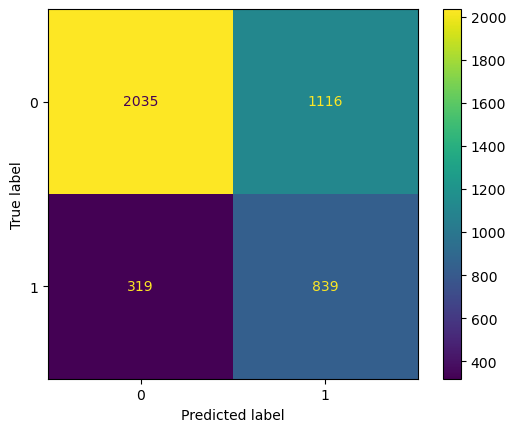

In [37]:
# 1. Confusion matrices

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)
plt.show()

<Figure size 1000x800 with 0 Axes>

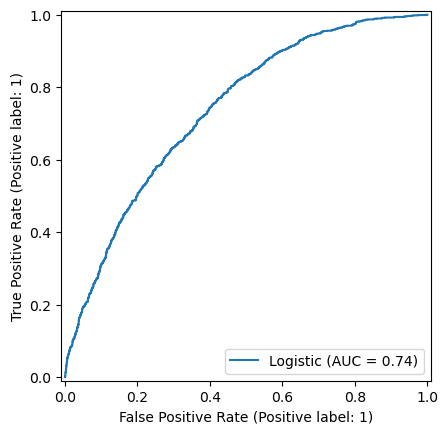

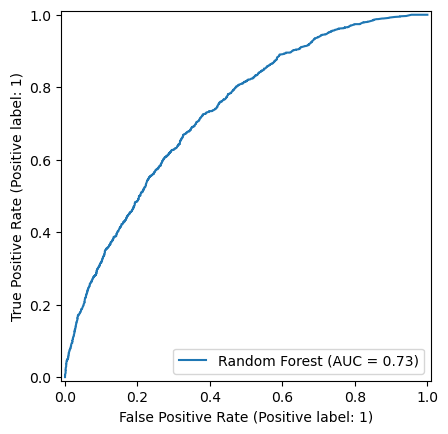

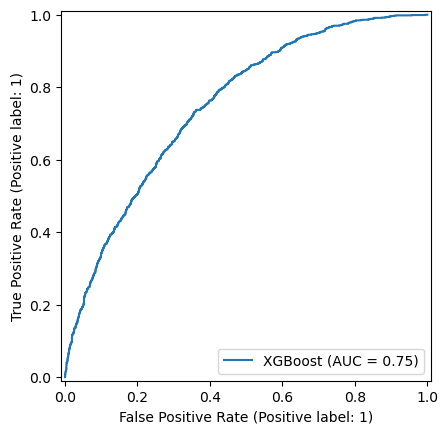

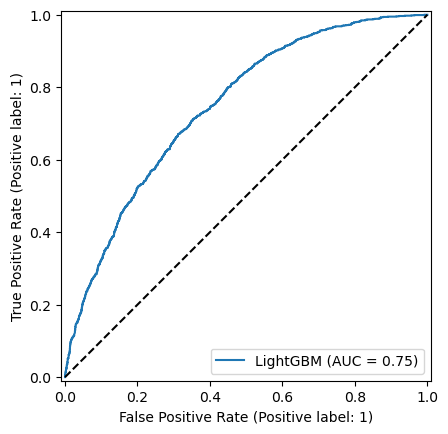

In [38]:
# 2. ROC curves

from sklearn.metrics import RocCurveDisplay

models = {
    'Logistic': log_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

plt.figure(figsize=(10,8))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.plot([0,1],[0,1],'k--')
plt.show()

In [39]:
# 3. Feature importance

# For XGBoost:

importance_values = xgb_model.named_steps[
    'classifier'
].feature_importances_

feature_names = xgb_model.named_steps[
    'preprocessor'
].get_feature_names_out()

print(len(feature_names))
print(len(importance_values))

111
111


In [40]:
# Create the importance dataframe
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(30)

,Feature,Importance
108,cat__HV270_5,0.143180
109,cat__HV025_1,0.037034
51,cat__survey_year_2010,0.032894
110,cat__HV025_2,0.032664
107,cat__HV270_4,0.026063
9,num__min_temperature,0.021741
8,num__max_temperature,0.018614
73,cat__HV205_12,0.016238
30,cat__state_Katsina,0.015091
46,cat__state_Zamfara,0.013643


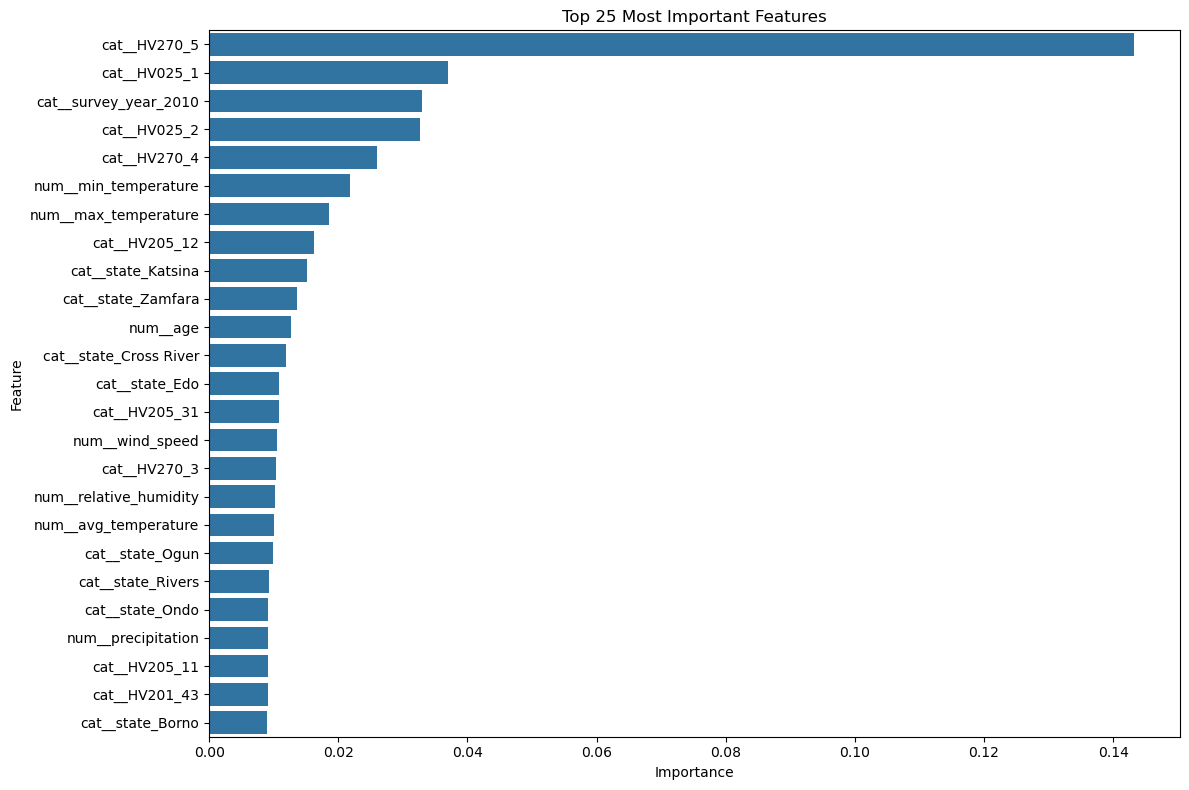

In [41]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(25),
    x='Importance',
    y='Feature'
)

plt.title('Top 25 Most Important Features')
plt.tight_layout()
plt.show()

# 4. SHAP values
This will tell US:

whether temperature increases malaria risk;
whether rainfall increases risk;
whether wealth decreases risk;
whether LLIN use reduces risk.

In [1]:
# Install:
!pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached numpy-2.5.0-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.6 MB 1.9 MB/s eta 0:00:09
   -- ------------------------------------- 1.0/15.6 MB 2.0 MB/s eta 0:00:08
   ---- ----------------------------------- 1.6/15.6 MB 2.1 MB/s eta 0:00:07
   ---- ----------------------------------- 1.8/15.6 MB 2.1 MB/s eta 0:00:07
   ------ --------------------------------- 2.4/15.6 MB 2.0 MB/s eta 0:00:07
   ------- -----------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


In [43]:
print(xgb_model.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'HV216', 'HV220', 'HML1',
                                  'avg_temperature', 'relative_humidity',
                                  'wind_speed', 'precipitation',
                                  'max_temperature', 'min_temperature']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['state', 'slept_under_treated_net',
                   

In [44]:
xgb = xgb_model.named_steps['classifier']

In [45]:
preprocessor = xgb_model.named_steps['preprocessor']

In [46]:
X_test_transformed = preprocessor.transform(X_test)

In [47]:
feature_names = preprocessor.get_feature_names_out()

In [48]:
import shap

explainer = shap.TreeExplainer(xgb)

In [49]:
shap_values = explainer.shap_values(X_test_transformed)

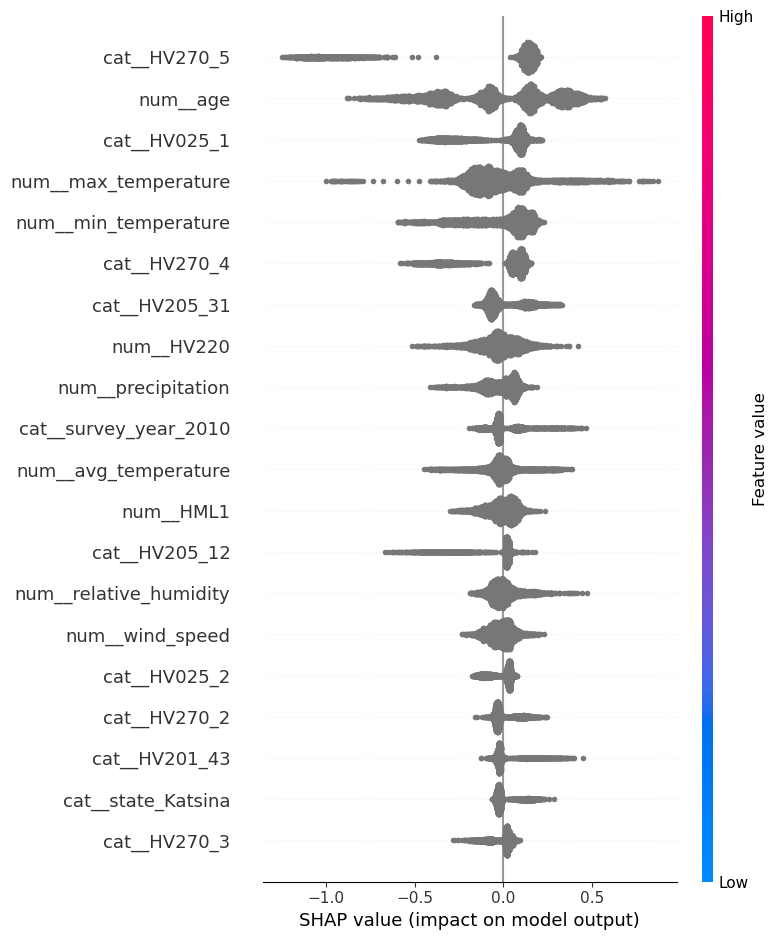

In [50]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

Partial Dependence Plots (Optional but impressive)

These answer:

How much does malaria risk change as temperature increases?

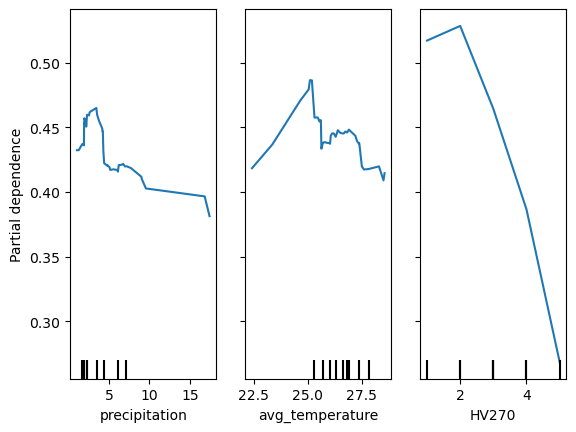

In [51]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test,
    features=[
        'precipitation',
        'avg_temperature',
        'HV270'
    ]
)

plt.show()